In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
ROOT = Path("..")
LOG_DIR = ROOT / "logs" / "wsd_intermediate_paper_decay_20260605-154459"

with open(LOG_DIR / "metrics.jsonl") as f:
    df = pd.DataFrame(json.loads(line) for line in f)

train = df[df["train_loss"].notna()].reset_index(drop=True)

DECAY_START = 800
print(f"Steps: {train['step'].min()} → {train['step'].max()}  ({len(train)} rows)")
print(f"Decay starts at step {DECAY_START}")

Steps: 5 → 1000  (200 rows)
Decay starts at step 800


In [3]:
def add_decay_line(ax, decay_start=DECAY_START):
    ax.axvline(decay_start, color="black", linestyle="--", linewidth=0.8, alpha=0.6, label="Decay start")

def plot_metric(ax, col, ylabel=None, color="steelblue"):
    ax.plot(train["step"], train[col], color=color, linewidth=1.0)
    add_decay_line(ax)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel or col)
    ax.set_title(ylabel or col)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

## Loss metrics

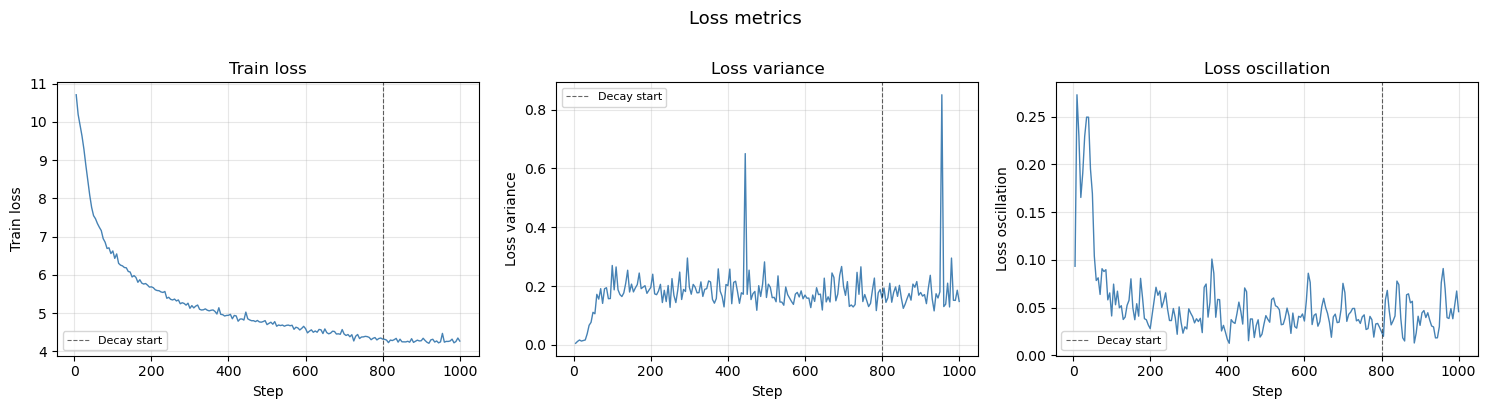

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_metric(axes[0], "train_loss",          "Train loss")
plot_metric(axes[1], "loss_variance",       "Loss variance")
plot_metric(axes[2], "loss_oscillation",    "Loss oscillation")

plt.suptitle("Loss metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

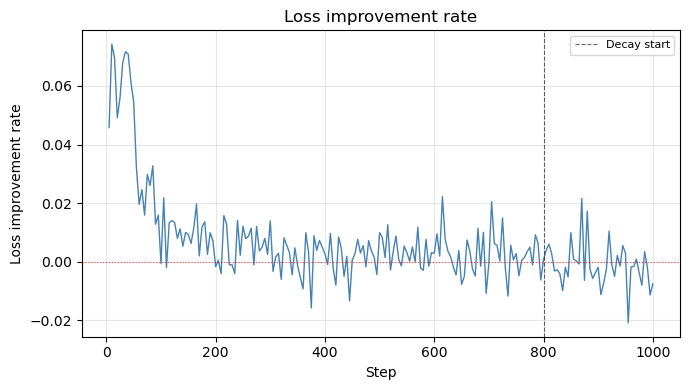

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_metric(ax, "loss_improvement_rate", "Loss improvement rate")
ax.axhline(0, color="red", linestyle=":", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

## Gradient metrics

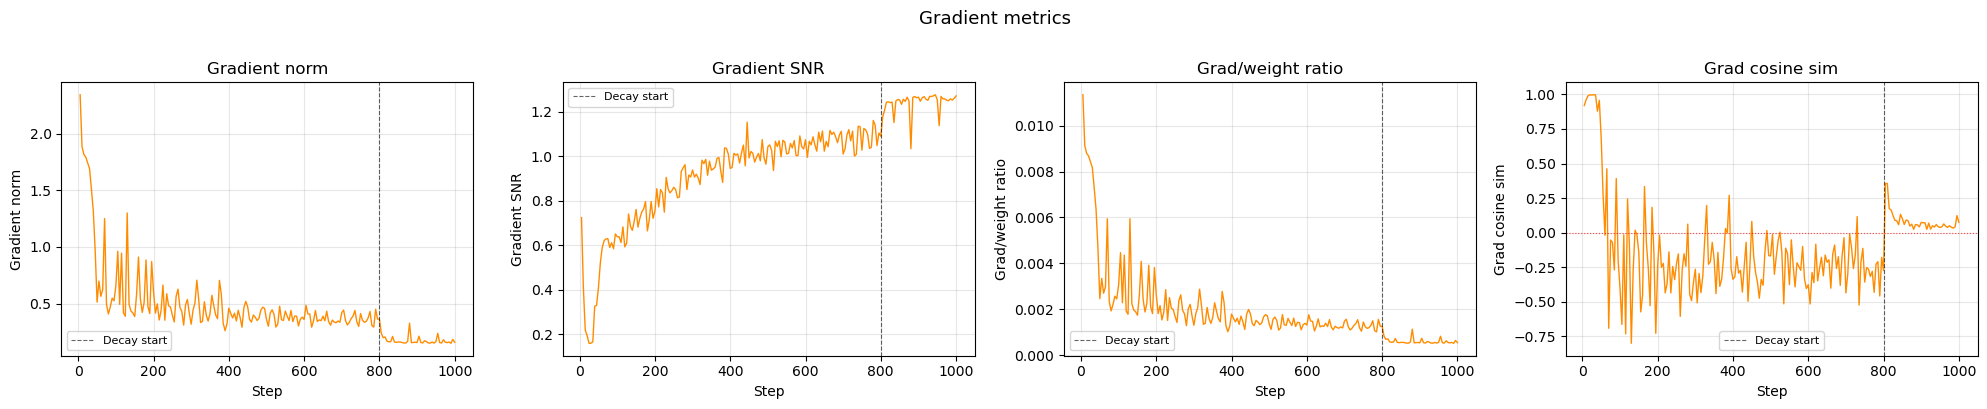

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

plot_metric(axes[0], "grad_norm",        "Gradient norm",       color="darkorange")
plot_metric(axes[1], "grad_snr",         "Gradient SNR",        color="darkorange")
plot_metric(axes[2], "grad_weight_ratio","Grad/weight ratio",   color="darkorange")
plot_metric(axes[3], "grad_cosine_sim",  "Grad cosine sim",     color="darkorange")

# reference line at 0 for cosine sim
axes[3].axhline(0, color="red", linestyle=":", linewidth=0.8, alpha=0.7)

plt.suptitle("Gradient metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Weight & update metrics

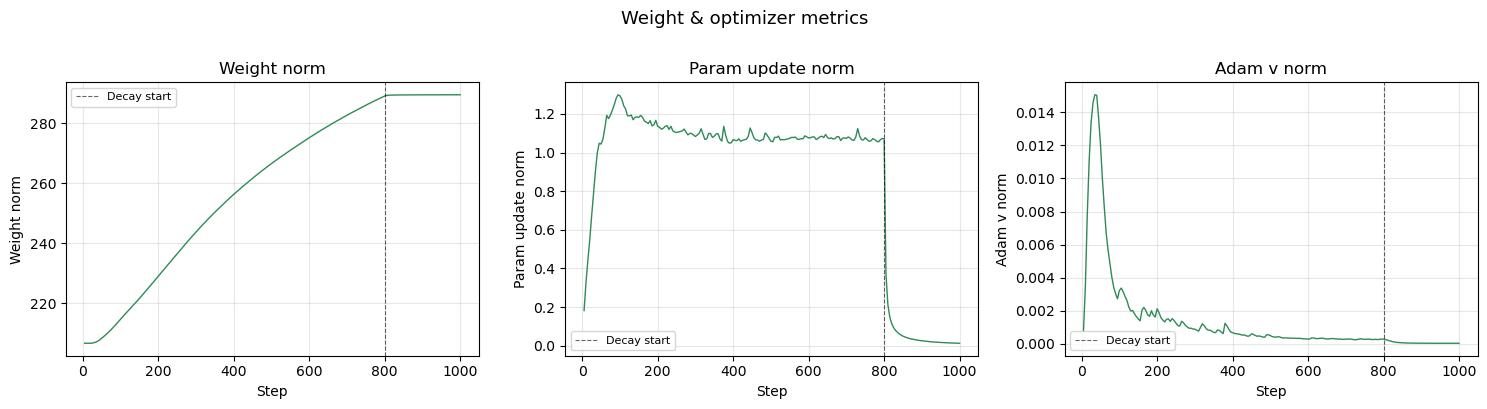

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_metric(axes[0], "weight_norm",       "Weight norm",       color="seagreen")
plot_metric(axes[1], "param_update_norm", "Param update norm", color="seagreen")
plot_metric(axes[2], "adam_v_norm",       "Adam v norm",       color="seagreen")

plt.suptitle("Weight & optimizer metrics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Learning rate

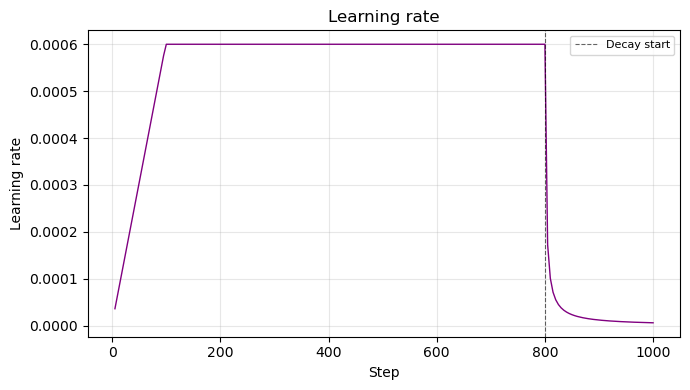

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_metric(ax, "learning_rate", "Learning rate", color="purple")
plt.tight_layout()
plt.show()

## All metrics — overview grid

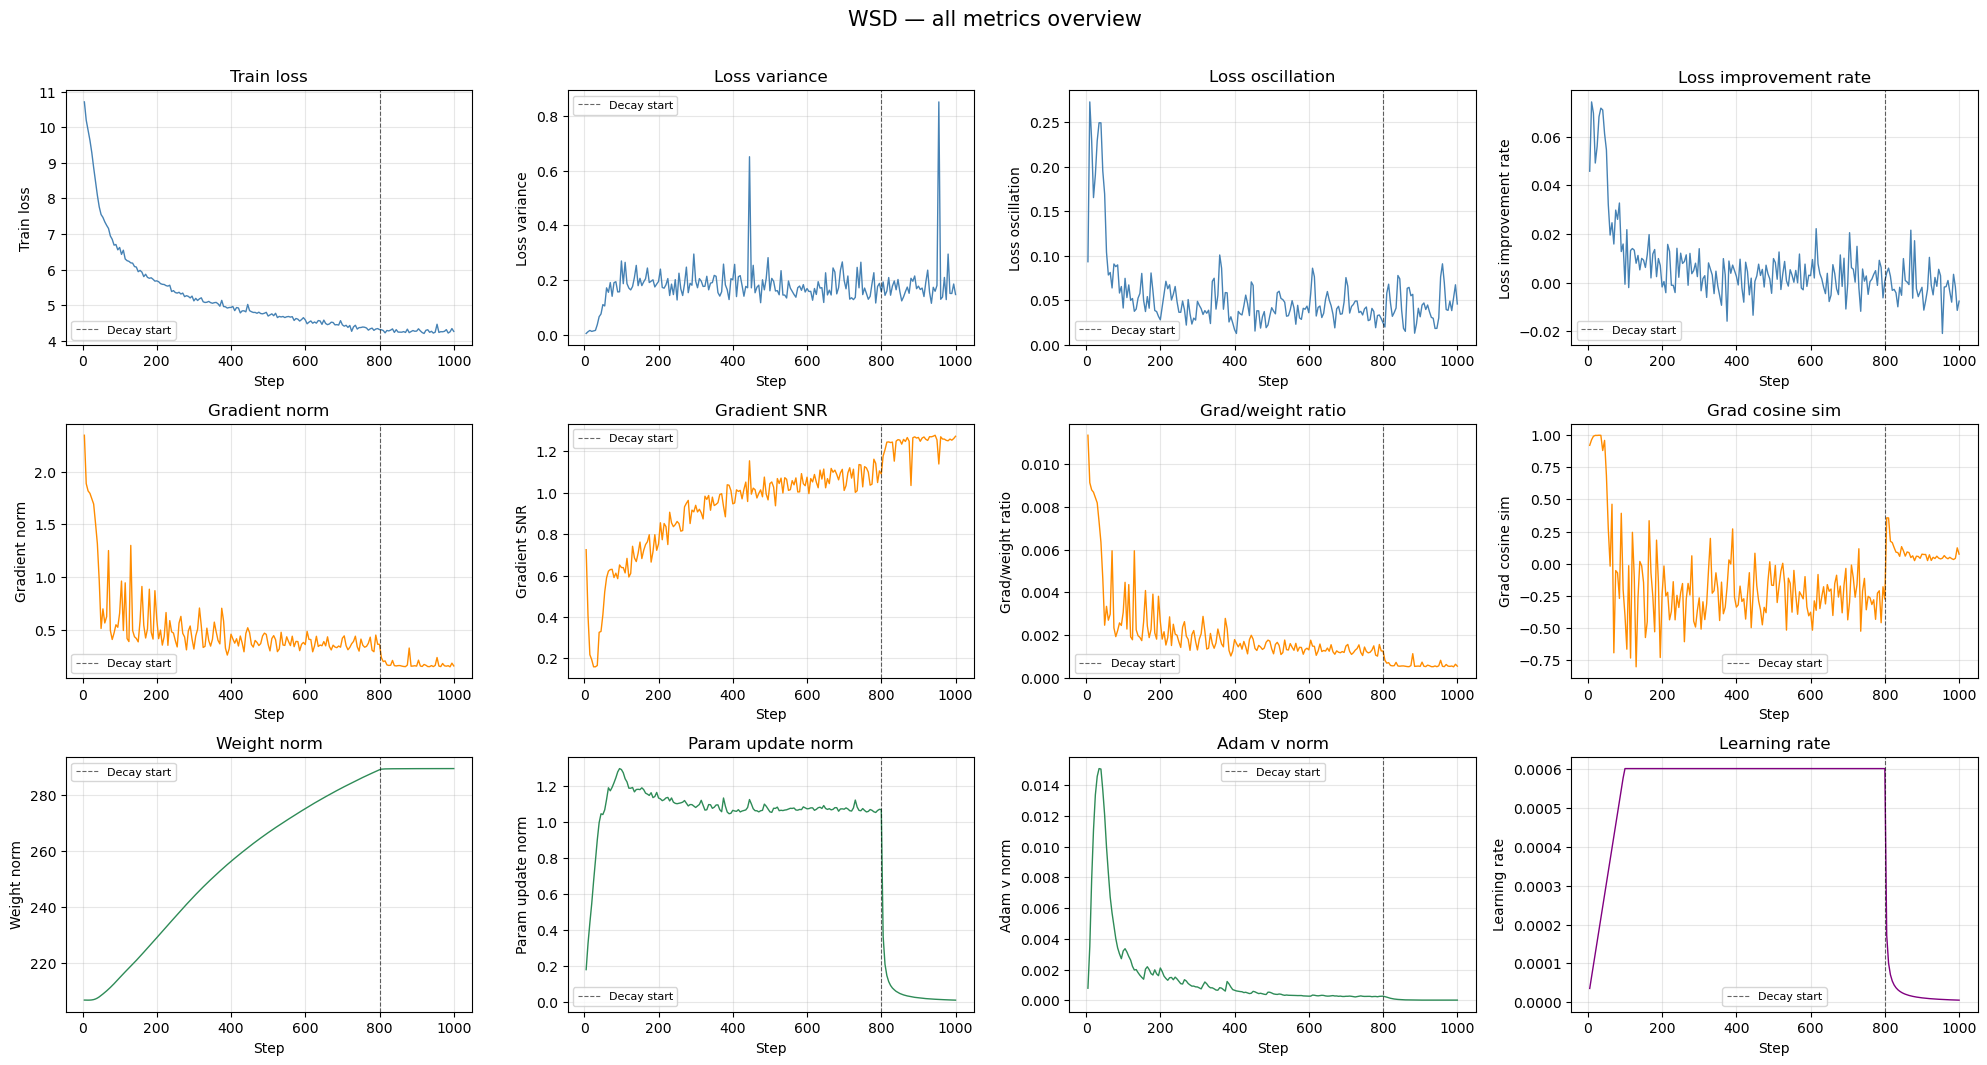

In [9]:
metrics = [
    ("train_loss",          "Train loss",          "steelblue"),
    ("loss_variance",       "Loss variance",        "steelblue"),
    ("loss_oscillation",    "Loss oscillation",     "steelblue"),
    ("loss_improvement_rate", "Loss improvement rate", "steelblue"),
    ("grad_norm",           "Gradient norm",        "darkorange"),
    ("grad_snr",            "Gradient SNR",         "darkorange"),
    ("grad_weight_ratio",   "Grad/weight ratio",    "darkorange"),
    ("grad_cosine_sim",     "Grad cosine sim",      "darkorange"),
    ("weight_norm",         "Weight norm",          "seagreen"),
    ("param_update_norm",   "Param update norm",    "seagreen"),
    ("adam_v_norm",         "Adam v norm",          "seagreen"),
    ("learning_rate",       "Learning rate",        "purple"),
]

ncols = 4
nrows = (len(metrics) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, metrics):
    plot_metric(ax, col, label, color)

for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.suptitle("WSD — all metrics overview", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()